# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isnull().mean())

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who','adult_male','class','deck','embark_town','alone'] # điền danh sách cột cần bỏ (chỉ những cột có trong df)
leaky = [col for col in leaky if col in df.columns]
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Vì thực chất ý nghĩa của cột alive giống 100% với cột target (là cột survived) nhưng được biểu diễn dưới dạng chữ. Suy ra, nếu giữ lại cột này thì mô hình sẽ học được quy luật dự đoán, từ đó dẫn đến bị rò rỉ thông tin. Điều này khiến Accuracy cao khi dự đoán trên dataset này, nhưng model không học dựa trên các feature thực tế khác (age, sex, pclass,...), như vậy model sẽ vô dụng khi dự đoán trên một bộ dataset mới hoàn toàn (không có cột alive).

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
# 1. In số dòng và số cột; biến mục tiêu (target)
print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
print("Biến mục tiêu (target): 'survived'")

# 2. Xem kiểu dữ liệu và số giá trị non-null
print("-------------------------------")
print("Thông tin cấu trúc dữ liệu: ")
df.info()

# 3. Thống kế các biến số
print("-------------------------------")
print("Thống kê các biến số: ")
print(df.describe())

# 3. Thống kê các biến phân loại
print("-------------------------------")
print("Thống kê các biến phân loại: ")
print(df.describe(include=['object','category']))

Kích thước dữ liệu: 891 dòng, 8 cột
Biến mục tiêu (target): 'survived'
-------------------------------
Thông tin cấu trúc dữ liệu: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
-------------------------------
Thống kê các biến số: 
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0

**Trả lời 2 (biến số vs biến phân loại):**

Cột biến số: survived, pclass, age, sibsp, parch, fare |
Cột biến phân loại: sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    'Số lượng thiếu: ': missing_count,
    'Phần trăm thiếu (%): ': missing_percent
})

print(missing_table[missing_table['Số lượng thiếu: '] > 0])

          Số lượng thiếu:   Phần trăm thiếu (%): 
age                    177              19.865320
embarked                 2               0.224467


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
|age|~19.87%|Median|Thường ảnh hưởng bởi outliers (người già & trẻ em)|
|embarked| ~0.22% | Mode |Vì đây là biến phân loại và tỉ lệ thiếu cũng rất ít |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    q1 = s.quantile(0.25)    # trả về số lượng outlier theo IQR
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s_clean = s.dropna()    # loại bỏ NaN trước khi tính toán z-score để tính toán lỗi
    z = np.abs(stats.zscore(s_clean))
    return (z > nguong).sum()  # trả về số lượng outlier theo Z-score

for col in ["age", "fare"]:
    print(f"Cột [{col}]:")
    print(f"  - Số outlier theo IQR: {dem_outlier_iqr(df[col])}")
    print(f"  - Số outlier theo Z-score: {dem_outlier_zscore(df[col])}")

Cột [age]:
  - Số outlier theo IQR: 11
  - Số outlier theo Z-score: 2
Cột [fare]:
  - Số outlier theo IQR: 116
  - Số outlier theo Z-score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

Giữ lại. Vì các outliers trong cột fare này phản ánh các giá trị vé cao bất thường dành cho những hành khách giàu có. Những người này sẽ thường có tỉ lệ sống sót cao hơn vì có vị trí cabin an toàn hơn, quyền ưu tiên lên thuyền cứu hộ,...Nên nếu loại bỏ, mô hình sẽ mất đi thông tin quan trọng để dự đoán tỉ lệ sống sót của các hành khách.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

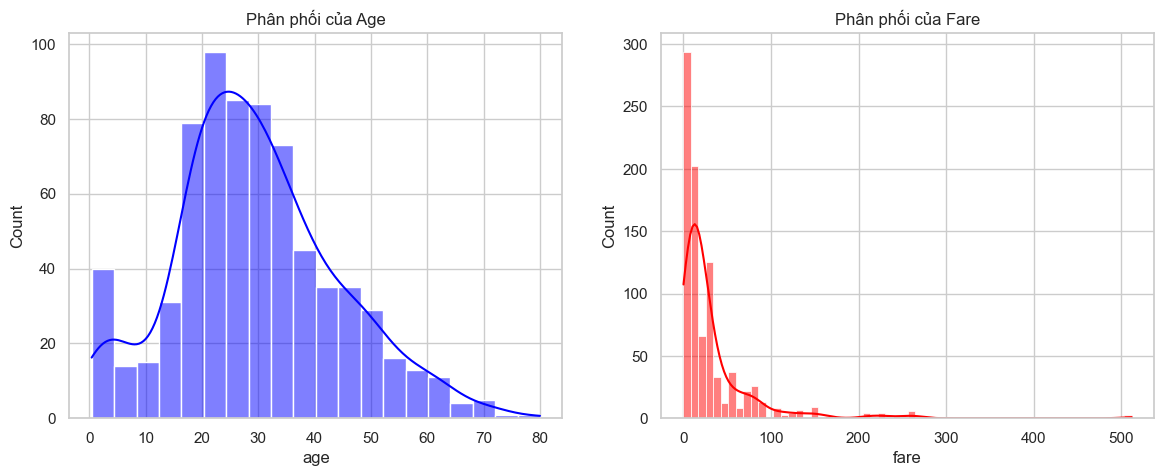

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['age'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Phân phối của Age')
sns.histplot(df['fare'], kde=True, ax=axes[1], color='red')
axes[1].set_title('Phân phối của Fare')
plt.show()

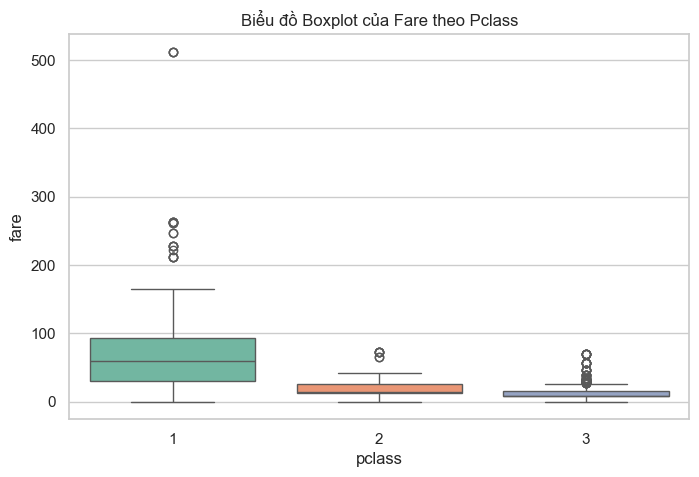

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', hue='pclass', palette='Set2', legend=False)
plt.title('Biểu đồ Boxplot của Fare theo Pclass')
plt.show()

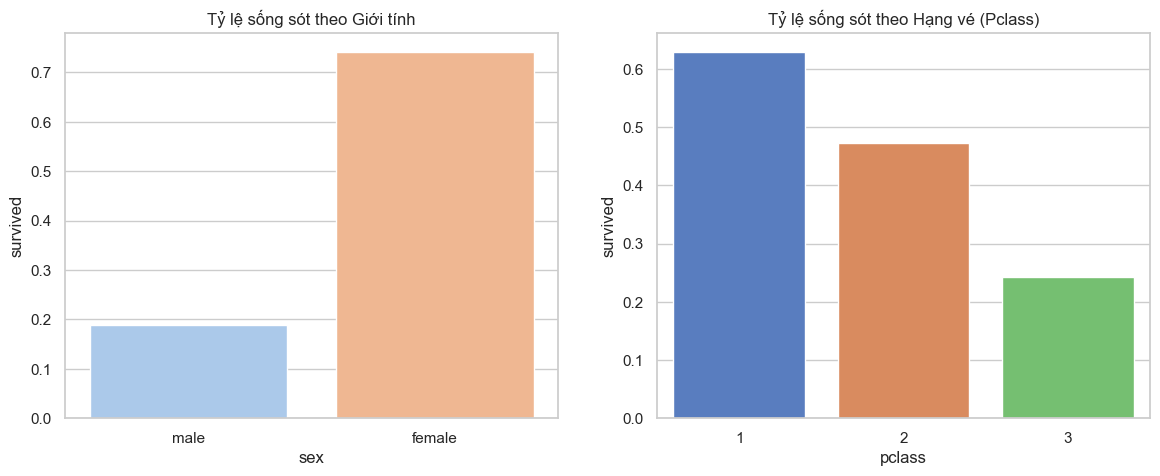

In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], errorbar=None, palette='pastel', hue='sex', legend=False)
axes[0].set_title('Tỷ lệ sống sót theo Giới tính')
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], errorbar=None, palette='muted', hue='pclass', legend=False)
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé (Pclass)')
plt.show()

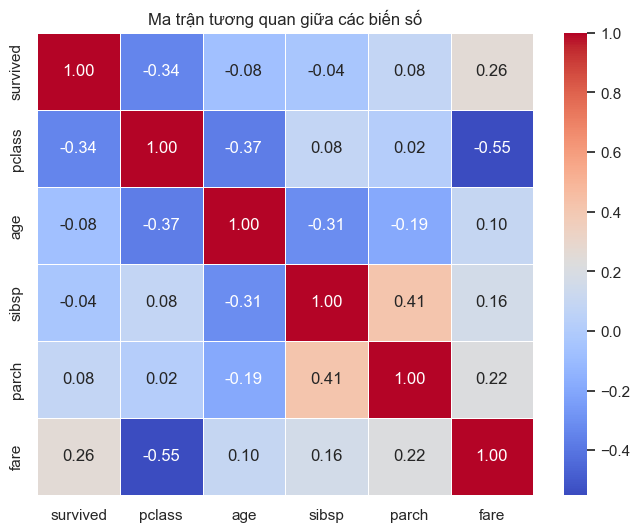

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Biến age có phân phối gần chuẩn nhưng hơi lệch phải nhẹ, tập trung nhiều ở độ tuổi 20-40. Biến fare có phân phối lệch phải rất nặng, phần lớn hành khách mua vé giá rẻ và có một số ít mua vé giá cực kỳ cao (outliers)
- Boxplot: Vé hạng 1 có dải giá trị rộng nhất, trung vị cao vượt trội và chứa nhiều outlier có giá trị rất lớn, hạng 3 có giá vé thấp nhất và phân phối rất hẹp
- Bar survival: Nữ giới có tỉ lệ sống sót cao hơn rất nhiêu so với nam giới. Hành khách ở hạng vé 1 có tỉ lệ sống sót cao nhất và sau đó giảm dần ở hạng vé 2 rồi đến hạng vé 3
- Heatmap: fare và pclass là cặp biến số có mối tương quan nghịch rõ nhất (-0.55), nghĩa là hạng vé càng nhỏ (1) thì giá vé càng cao. Ngoài ra pclass cũng tương quan nghịch với survived (-0.34), nghĩa là hạng vé càng nhỏ thì tỉ lệ sống sót càng cao

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.1765, random_state=42, stratify=y_tmp)

print(f"Train/Val/Test:{y_train.mean(): .4f} /{y_val.mean(): .4f} /{y_test.mean(): .4f}")
# in tỷ lệ survived từng tập

Train/Val/Test: 0.3836 / 0.3881 / 0.3806


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", pipe_so,  num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Vì nếu fit trên toàn dataset trước khi chia tập thì thông tin từ validation set và test set sẽ bị lọt vào quá trình tính toán các thông số thống kế của các biến, dẫn tới hiện tượng data leakage. Lúc đó thì kết quả đánh giá mô hình sẽ bị ảo và giảm độ chính xác khi đối mặt dữ liệu thực tế.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df['survived'].value_counts(normalize=True))

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Biến mục tiêu survived có sự mất cân bằng nhưng chỉ ở mức nhẹ
2. Nếu chỉ nhìn Accuracy thì có thể sẽ bị đánh lừa trong trường hợp dữ liệu bị mất cân bằng nghiêm trọng (ví dụ như dự đoán tỉ lệ người bị ung thư, accuracy có thể lên tới hơn 90% nếu luôn dự đoán là "không ung thư" vì số lượng người thật sự bị ung thư trong bộ dữ liệu là rất ít)
3. Với bài toán Titanic, ta nên ưu tiên metric F1 vì bài toán này coi trọng việc nhận diện chính xác cả 2 nhóm (vừa muốn tránh bỏ sót và cũng muốn tránh nhầm lẫn)

 ---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Feature tương quan mạnh nhất với survived là pclass (tương quan nghịch, với hệ số tương quan là -0.34) => Tương quan mạnh nhất trong các biến số
2. Cột age thiếu nhiều nhất và đã được điền bằng median để tránh ảnh hưởng bởi outliers
3. Biến mục tiêu bị mất cân bằng nhẹ nên việc chọn metric như F1 sẽ tốt hơn là chỉ sử dụng Accuracy để đánh giá mô hình
4. Features cần được scaling là age và fare, vì phân phối của các biến này bị lệch nên cần phải scale lại để không bị méo thang đo. Ngoài ra, các features như sex, embarked cần được encoding bằng OneHotEncoder để chuyển từ dạng chữ sang các vector số
5. Mặc dù số lượng hành khách ở vé hạng 3 đông nhất nhưng số lượng sống sót lại tập trung nhiều ở vé hạng 1

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

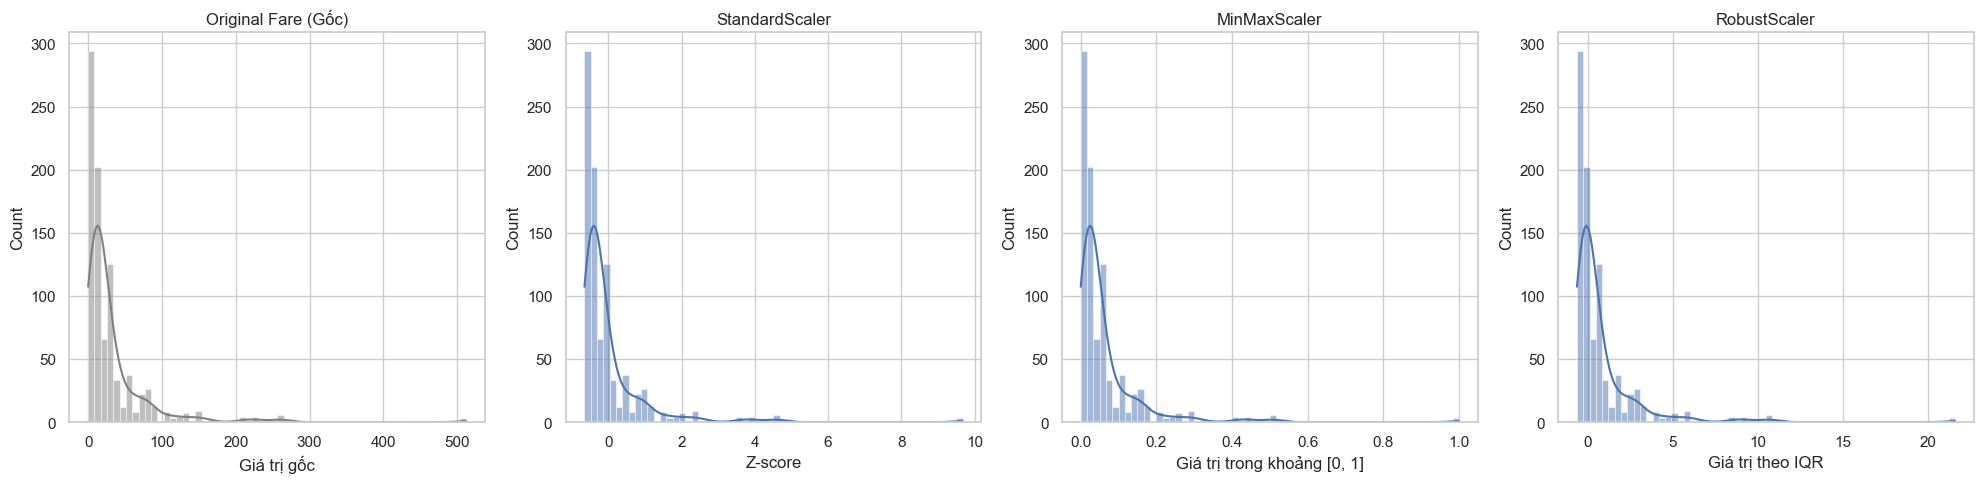

In [14]:
# (tùy chọn) code cho phần Bonus
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Lấy dữ liệu fare (loại bỏ NaN nếu có để vẽ biểu đồ không bị lỗi)
fare_data = df[['fare']].dropna()

# Khởi tạo các bộ scalers
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()
robust_scaler = RobustScaler()

# Thực hiện scale dữ liệu
fare_std = std_scaler.fit_transform(fare_data)
fare_minmax = minmax_scaler.fit_transform(fare_data)
fare_robust = robust_scaler.fit_transform(fare_data)

# Trực quan hóa bằng Subplots (1 hàng, 4 cột)
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

# 1. Dữ liệu gốc
sns.histplot(fare_data['fare'], kde=True, ax=axes[0], color='gray')
axes[0].set_title("Original Fare (Gốc)")
axes[0].set_xlabel("Giá trị gốc")

# 2. StandardScaler
sns.histplot(fare_std, kde=True, ax=axes[1], color='blue', legend=False)
axes[1].set_title("StandardScaler")
axes[1].set_xlabel("Z-score")

# 3. MinMaxScaler
sns.histplot(fare_minmax, kde=True, ax=axes[2], color='green', legend=False)
axes[2].set_title("MinMaxScaler")
axes[2].set_xlabel("Giá trị trong khoảng [0, 1]")

# 4. RobustScaler
sns.histplot(fare_robust, kde=True, ax=axes[3], color='red', legend=False)
axes[3].set_title("RobustScaler")
axes[3].set_xlabel("Giá trị theo IQR")

plt.tight_layout()
plt.show()

### Nhận xét hệ quả của các phương pháp Scaling trên cột 'fare'

* **Original Fare (Dữ liệu gốc):**
  * *Thang đo:* Chạy từ `0` đến hơn `500` (đơn vị đô la thực tế).
  * *Hạn chế:* Vùng dữ liệu số đông (vé giá rẻ) tập trung quá dày ở sát vạch 0, trong khi các tấm vé VIP tạo ra một cái đuôi quá dài về phía bên phải.

* **StandardScaler (Chuẩn hóa Z-score):**
  * *Thang đo:* Chạy từ khoảng `-1` đến gần `10`. Số `0` chính là giá trị trung bình (Mean).
  * *Nhược điểm do outlier:* Vì công thức tính có chứa độ lệch chuẩn ($\sigma$) - một đại lượng bị ảnh hưởng nặng nề bởi các giá trị cực đại - nên các tấm vé VIP giá cao đã kéo $\sigma$ lớn lên. Hệ quả là phần "bụng" dữ liệu số đông bị nén chặt lại xung quanh khoảng sát mức 0, làm giảm khả năng phân tách giữa các mức vé phổ thông thấp.

* **MinMaxScaler (Đưa về khoảng [0, 1]):**
  * *Thang đo:* Bị ép cứng trong phạm vi từ `0.0` đến `1.0`.
  * *Nhược điểm do outlier:* Tấm vé đắt nhất chiếm giữ vị trí tuyệt đối là `1.0`. Điều này vô tình bắt khoảng hơn 90% lượng dữ liệu còn lại phải co cụm lại trong một không gian cực kỳ chật hẹp từ `0.0` đến `0.2`. Khi đưa vào mô hình, sự chênh lệch nhỏ giữa các mức vé sẽ bị san phẳng, khiến mô hình khó học được sự khác biệt.

* **RobustScaler (Chuẩn hóa dựa trên Median và IQR):**
  * *Thang đo:* Chạy từ khoảng `-1` đến hơn `20`. Số `0` chính là **Trung vị (Median)**.
  * *Ưu điểm vượt trội:* Vì sử dụng Median và khoảng tứ phân vị (IQR) - những đại lượng bền vững (robust) không bị thao túng bởi outlier - RobustScaler đã kéo giãn vùng dữ liệu cốt lõi (vé phổ thông) ra một khoảng rộng rãi và rõ ràng hơn rất nhiều (từ `-1` đến gần `5`), trong khi vẫn cho phép các giá trị outlier tự do đẩy xa lên đến tận hơn `20` mà không làm méo mó phân phối vùng trung tâm.

---

#### Kết luận chọn lựa bộ Scaler phù hợp
> **Quyết định:** Đối với các đặc trưng có độ lệch lớn và chứa nhiều outlier thực tế như `fare`, **RobustScaler** là sự lựa chọn tối ưu nhất. Nó giúp mô hình Machine Learning dễ dàng phân biệt, học hỏi đặc trưng từ nhóm hành khách số đông một cách hiệu quả mà không bị làm nhiễu bởi các giá trị cực trị.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
